# 🧩 Clustering Students Based on Soft Skills Quiz Scores

This notebook demonstrates how to cluster students using their soft skills assessment results. The clustering is based on quiz scores for Communication, Leadership, Time Management, and Analytical Thinking.

## 1. Import Required Libraries

Import pandas, numpy, matplotlib, seaborn, and clustering algorithms from scikit-learn.

In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. Load Assessment Results Dataset

Load the CSV file containing student quiz scores (e.g., 'assessment_results.csv') into a pandas DataFrame.

In [14]:
# Instead of loading from a file, let's create simulated data
# Set random seed for reproducibility
np.random.seed(42)

# Generate simulated student assessment data
n_students = 100
student_ids = [f"STU{i:03d}" for i in range(1, n_students+1)]
student_names = [f"Student {i}" for i in range(1, n_students+1)]

# Create dictionary for DataFrame
data = {
    'student_id': student_ids,
    'student_name': student_names,
    'communication_score': np.random.uniform(1, 5, n_students).round(2),
    'leadership_score': np.random.uniform(1, 5, n_students).round(2),
    'time_management_score': np.random.uniform(1, 5, n_students).round(2),
    'analytical_score': np.random.uniform(1, 5, n_students).round(2)
}

# Create some patterns in the data for more realistic clusters
# Group 1: High communication, leadership (extroverts)
data['communication_score'][:25] += 0.7
data['leadership_score'][:25] += 0.5
# Group 2: High analytical, time management (analytical planners)
data['analytical_score'][25:50] += 0.7
data['time_management_score'][25:50] += 0.6
# Group 3: High leadership, low time management (natural leaders)
data['leadership_score'][50:75] += 0.8
data['time_management_score'][50:75] -= 0.3
# Group 4: Balanced profile (well-rounded)
# No adjustments needed for the last group

# Clip values to ensure they stay within 1-5 range
for score_col in ['communication_score', 'leadership_score', 'time_management_score', 'analytical_score']:
    data[score_col] = np.clip(data[score_col], 1.0, 5.0)

# Create DataFrame
scores_df = pd.DataFrame(data)

# Calculate overall score
scores_df['overall_score'] = scores_df[['communication_score', 'leadership_score', 
                                      'time_management_score', 'analytical_score']].mean(axis=1)

print(f"Created simulated data for {len(scores_df)} students.")
scores_df.head()

Created simulated data for 100 students.


,student_id,student_name,communication_score,leadership_score,time_management_score,analytical_score,overall_score
0,STU001,Student 1,3.20,1.63,3.57,1.21,2.4025
1,STU002,Student 2,5.00,4.05,1.34,3.13,3.3800
2,STU003,Student 3,4.63,2.76,1.65,3.16,3.0500
3,STU004,Student 4,4.09,3.53,4.59,3.55,3.9400
4,STU005,Student 5,2.32,5.00,3.43,3.90,3.6625


## 3. Preprocess Scores for Clustering

Select relevant score columns, handle missing values, and scale/normalize the data if necessary.

In [15]:
# Select relevant score columns
score_columns = [
    'communication_score',
    'leadership_score',
    'time_management_score',
    'analytical_score'
]

# Check for missing values and fill with column mean if needed
scores_df[score_columns] = scores_df[score_columns].apply(lambda x: x.fillna(x.mean()))

# Scale the scores for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(scores_df[score_columns])

print("Scores preprocessed and scaled for clustering.")

Scores preprocessed and scaled for clustering.


## 4. Perform Clustering on Student Scores

Apply clustering algorithms (KMeans and DBSCAN) to the students' scores and assign cluster labels.

In [16]:
# KMeans clustering
n_clusters = 4  # You can adjust this based on your needs
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
scores_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# DBSCAN clustering (optional, for comparison)
dbscan = DBSCAN(eps=1.0, min_samples=3)
scores_df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("Clustering complete. Cluster labels assigned.")

Clustering complete. Cluster labels assigned.


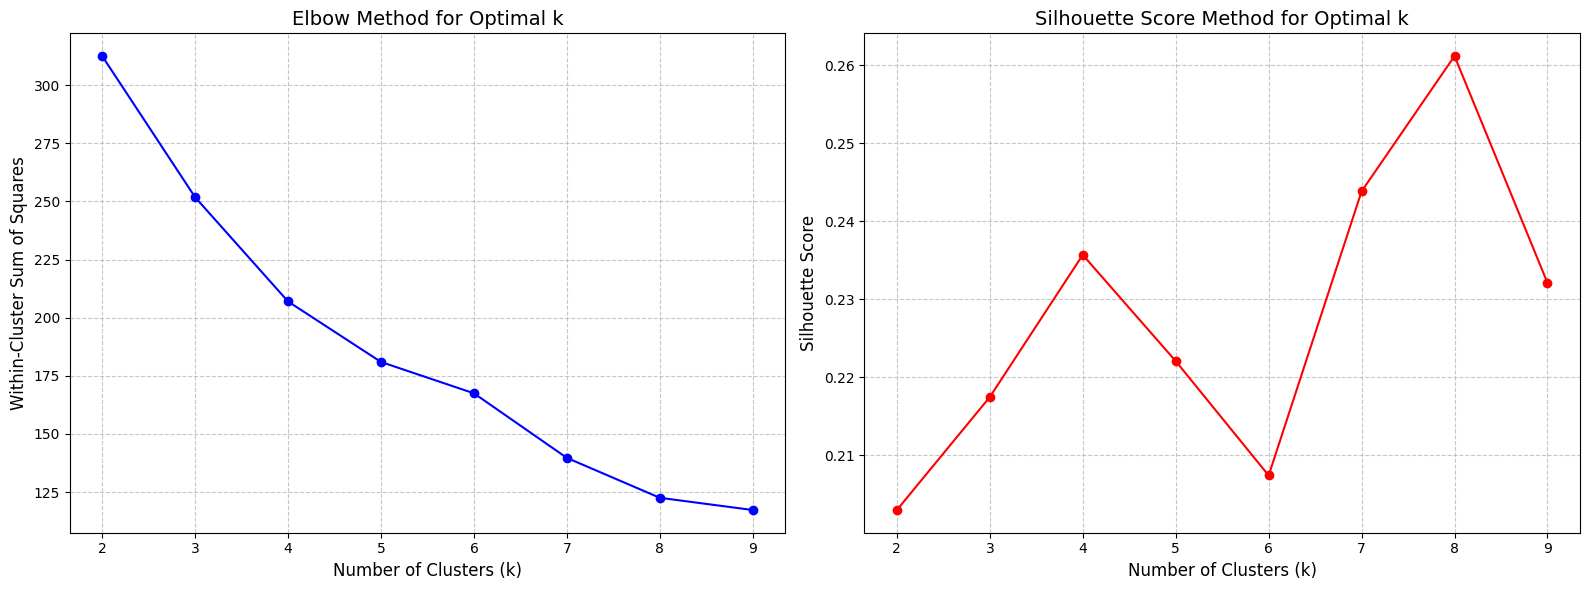

Optimal number of clusters based on silhouette score: 8


In [17]:
# Find optimal number of clusters using the Elbow Method
wcss = []  # Within-cluster sum of squares
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(X_scaled)
    wcss.append(kmeans_test.inertia_)
    
    # Calculate silhouette score
    cluster_labels = kmeans_test.predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plot WCSS (Elbow method)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-')
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.title('Silhouette Score Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Find the optimal k based on silhouette score
optimal_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")

# Use the optimal number of clusters
n_clusters = optimal_k

## 5. Visualize Clusters

Create visualizations (scatter plots, pair plots, or PCA plots) to show how students are grouped by clusters.

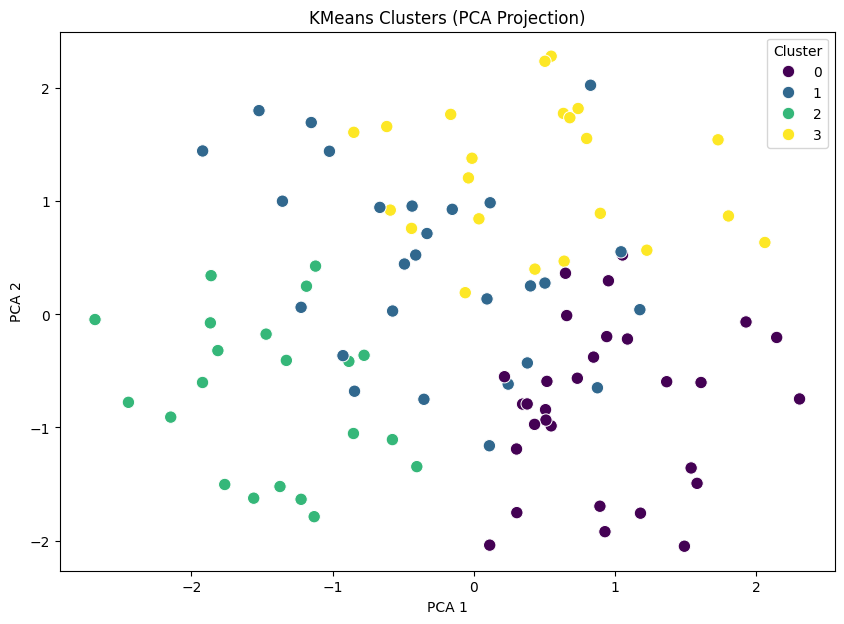

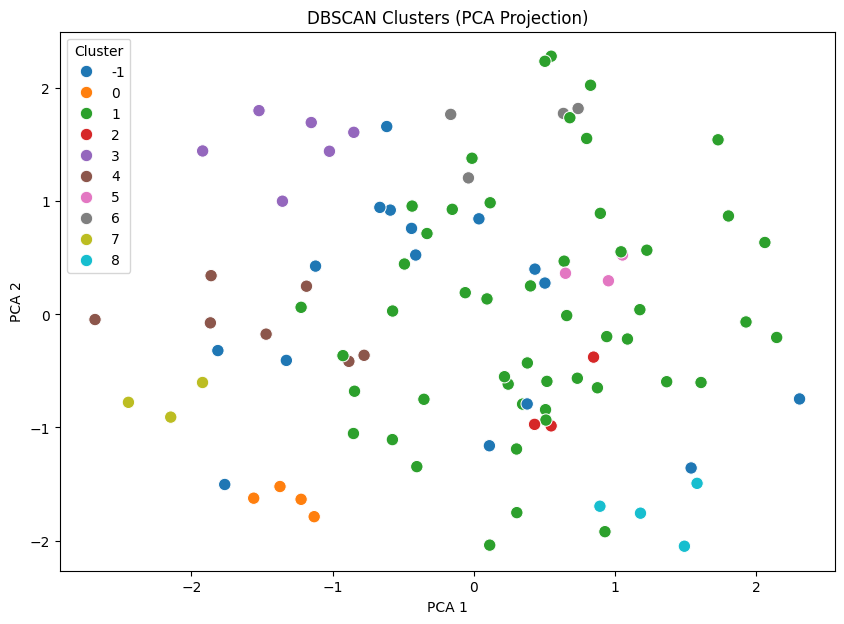

In [18]:
# Visualize clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=scores_df['kmeans_cluster'], palette='viridis', s=80)
plt.title('KMeans Clusters (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

# Optionally, visualize DBSCAN clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=scores_df['dbscan_cluster'], palette='tab10', s=80)
plt.title('DBSCAN Clusters (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

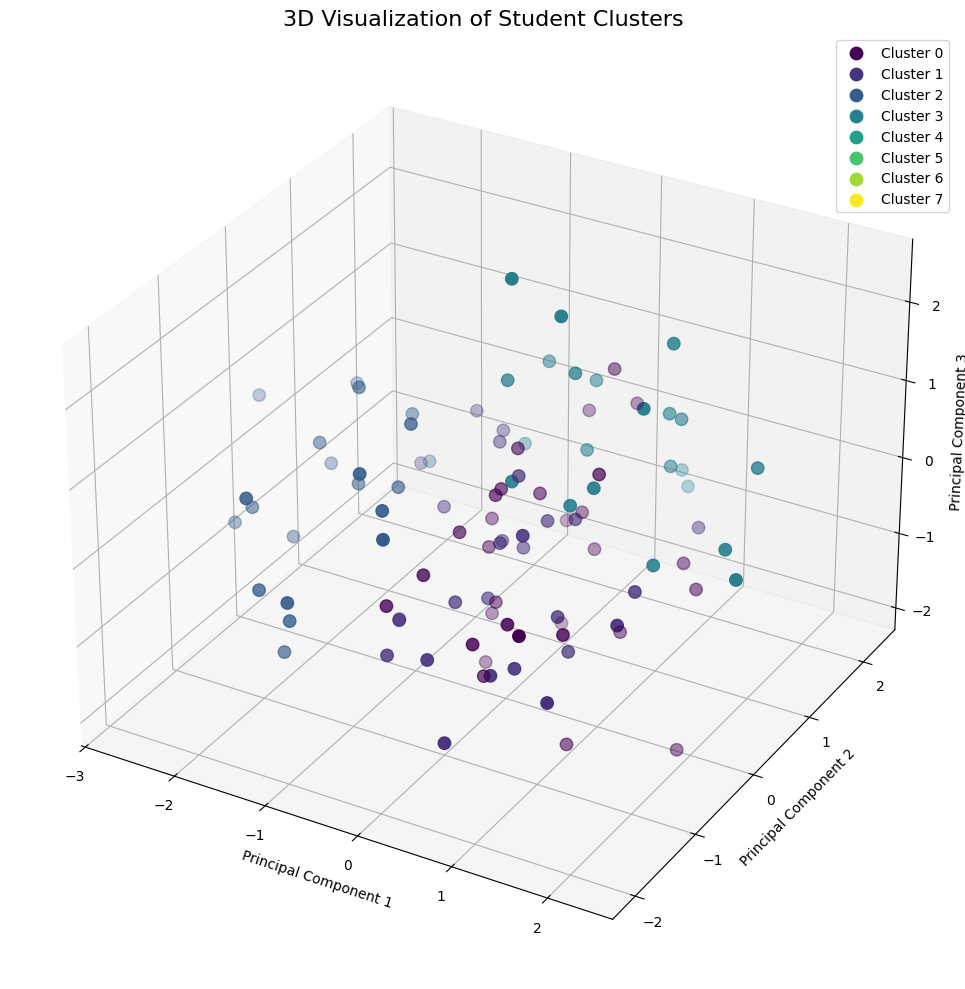

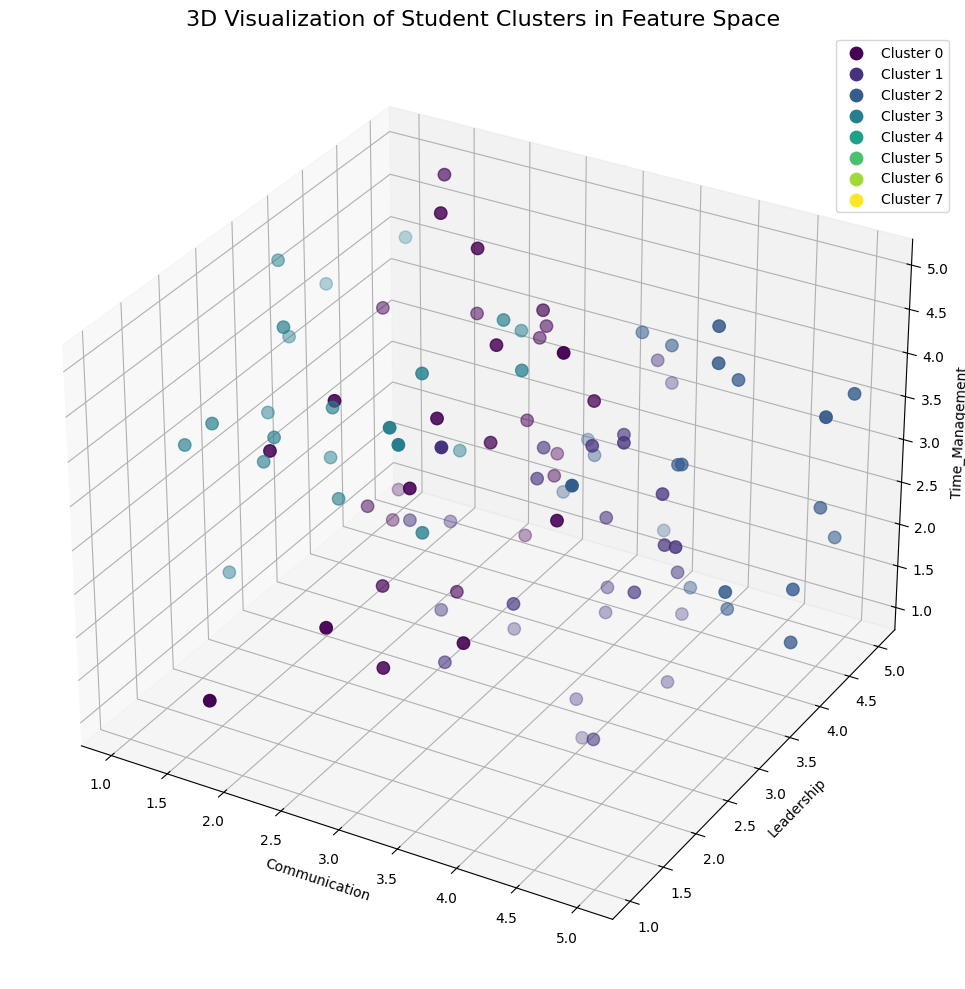

In [19]:
# Create a 3D visualization of the clusters using the first 3 components
from mpl_toolkits.mplot3d import Axes3D

# Get 3 principal components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a color map
colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))

# Plot each cluster
for i in range(n_clusters):
    # Get the points in this cluster
    cluster_points = X_pca_3d[scores_df['kmeans_cluster'] == i]
    
    # Plot these points
    ax.scatter(
        cluster_points[:, 0], 
        cluster_points[:, 1], 
        cluster_points[:, 2], 
        s=80,
        c=[colors[i]],
        label=f'Cluster {i}'
    )

# Add labels
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D Visualization of Student Clusters', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

# Create another 3D visualization using the actual features
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Select 3 of the original features for visualization
feature_indices = [0, 1, 2]  # communication, leadership, time_management
feature_names = [score_columns[i] for i in feature_indices]

# Plot each cluster
for i in range(n_clusters):
    # Get the data points in this cluster
    cluster_mask = scores_df['kmeans_cluster'] == i
    
    # Plot these points
    ax.scatter(
        scores_df.loc[cluster_mask, feature_names[0]], 
        scores_df.loc[cluster_mask, feature_names[1]], 
        scores_df.loc[cluster_mask, feature_names[2]],
        s=80,
        c=[colors[i]],
        label=f'Cluster {i}'
    )

# Add labels
ax.set_xlabel(feature_names[0].replace('_score', '').title())
ax.set_ylabel(feature_names[1].replace('_score', '').title())
ax.set_zlabel(feature_names[2].replace('_score', '').title())
ax.set_title('3D Visualization of Student Clusters in Feature Space', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

## 6. Analyze Cluster Characteristics

Calculate and display summary statistics for each cluster to interpret the soft skills profiles.

In [20]:
# Analyze cluster characteristics
print("KMeans Cluster Summary:")
for cluster in sorted(scores_df['kmeans_cluster'].unique()):
    print(f"\nCluster {cluster}:")
    cluster_data = scores_df[scores_df['kmeans_cluster'] == cluster]
    print(cluster_data[score_columns].describe())

print("\nDBSCAN Cluster Summary:")
for cluster in sorted(scores_df['dbscan_cluster'].unique()):
    print(f"\nCluster {cluster}:")
    cluster_data = scores_df[scores_df['dbscan_cluster'] == cluster]
    print(cluster_data[score_columns].describe())

KMeans Cluster Summary:

Cluster 0:
       communication_score  leadership_score  time_management_score  \
count            30.000000         30.000000               30.00000   
mean              2.111667          3.897333                2.68500   
std               0.573369          0.946860                1.21711   
min               1.100000          1.370000                1.04000   
25%               1.615000          3.215000                1.47250   
50%               2.255000          4.075000                2.74500   
75%               2.430000          4.707500                3.48750   
max               3.250000          5.000000                5.00000   

       analytical_score  
count          30.00000  
mean            4.07100  
std             0.56679  
min             3.07000  
25%             3.64750  
50%             4.06500  
75%             4.49000  
max             5.00000  

Cluster 1:
       communication_score  leadership_score  time_management_score  \
count  

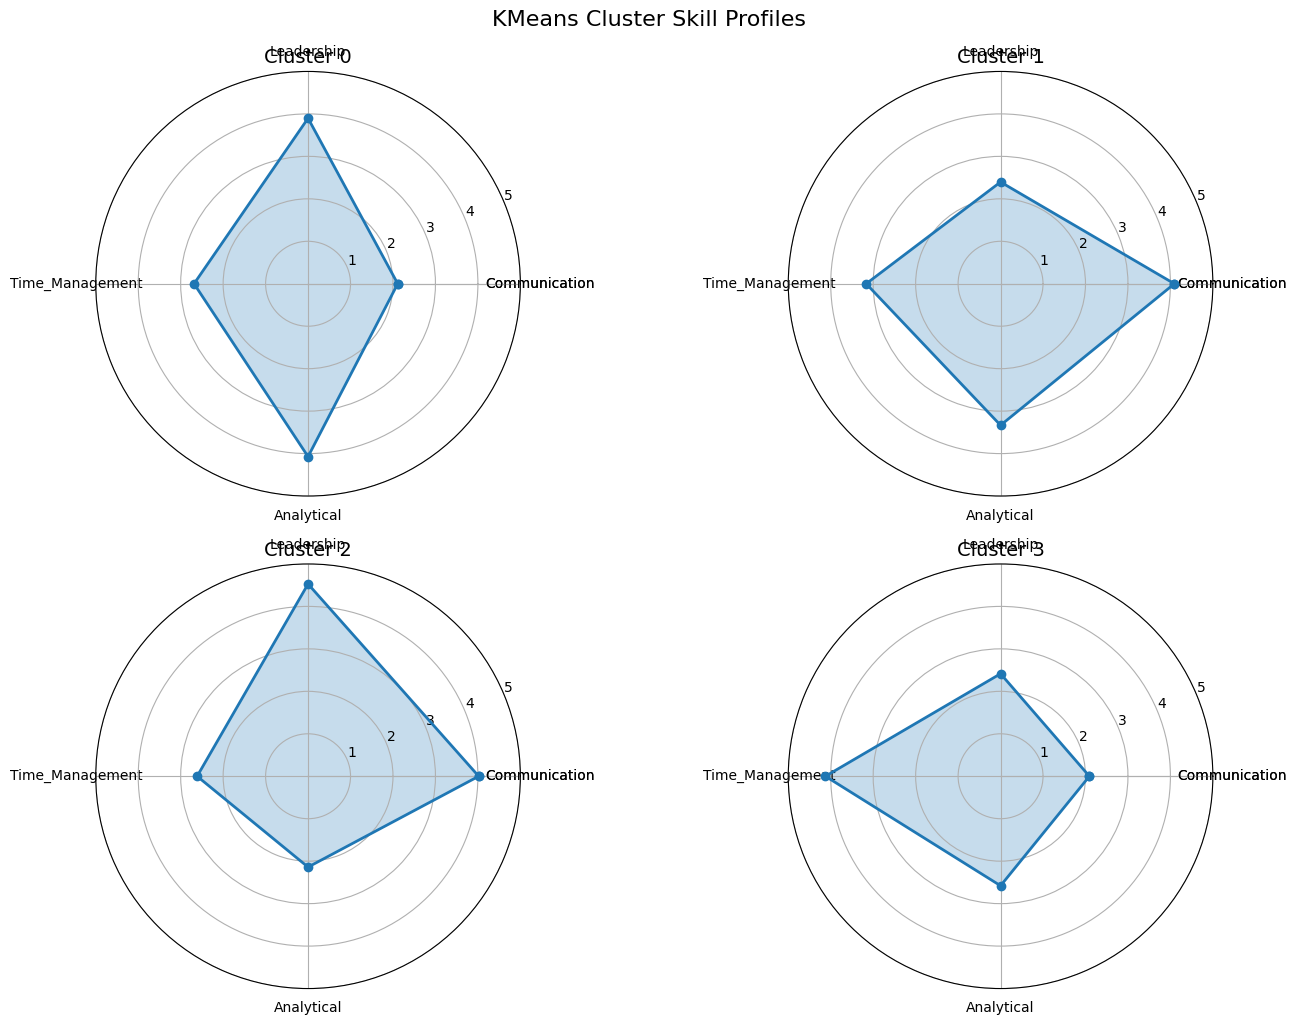

In [21]:
# Create radar charts to visualize the skill profiles of each cluster
def plot_cluster_radar(cluster_centers, score_columns, title):
    # Set up the figure
    fig = plt.figure(figsize=(14, 10))
    
    # Number of clusters
    n_clusters = len(cluster_centers)
    n_cols = 2
    n_rows = (n_clusters + 1) // 2
    
    # For each cluster, create a radar chart
    for i, (cluster_id, center) in enumerate(cluster_centers.items()):
        # Create subplot with polar projection
        ax = fig.add_subplot(n_rows, n_cols, i+1, polar=True)
        
        # Get the scores for this cluster
        values = [center[col] for col in score_columns]
        
        # Close the loop for the radar chart
        values += values[:1]
        
        # Set the angles for each axis
        angles = np.linspace(0, 2*np.pi, len(score_columns), endpoint=False).tolist()
        angles += angles[:1]  # Close the loop
        
        # Plot the values
        ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}')
        ax.fill(angles, values, alpha=0.25)
        
        # Set the labels
        labels = [col.replace('_score', '').title() for col in score_columns]
        labels += labels[:1]  # Close the loop
        ax.set_xticks(angles)
        ax.set_xticklabels(labels)
        
        # Set title for each subplot
        ax.set_title(f'Cluster {cluster_id}', size=14)
        
        # Set y limits
        ax.set_ylim(0, 5)
        
    plt.tight_layout()
    plt.suptitle(title, size=16, y=1.02)
    plt.show()

# Calculate cluster centers for KMeans
kmeans_centers = {}
for cluster in sorted(scores_df['kmeans_cluster'].unique()):
    cluster_data = scores_df[scores_df['kmeans_cluster'] == cluster]
    kmeans_centers[cluster] = cluster_data[score_columns].mean()

# Plot radar charts for KMeans clusters
plot_cluster_radar(kmeans_centers, score_columns, 'KMeans Cluster Skill Profiles')

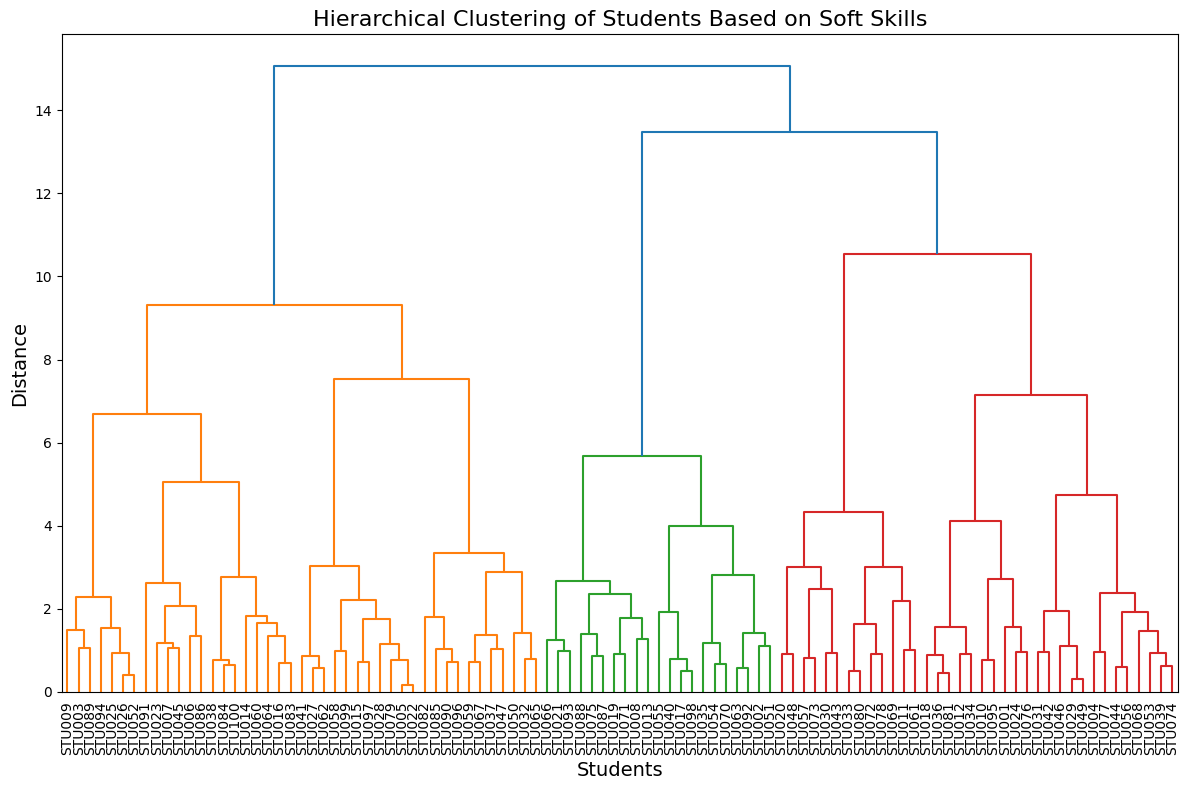

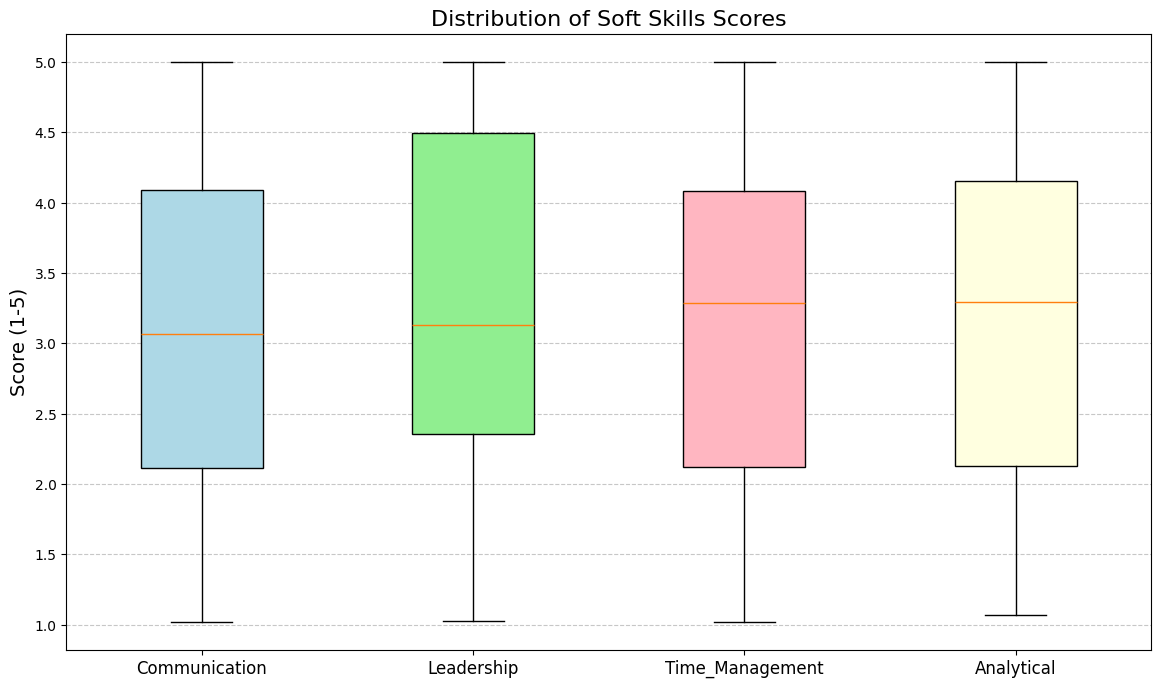

In [22]:
# Perform hierarchical clustering for visualization
from scipy.cluster.hierarchy import dendrogram, linkage

# Create a figure
plt.figure(figsize=(12, 8))

# Calculate the linkage matrix
Z = linkage(scores_df[score_columns], 'ward')

# Plot the dendrogram
dendrogram(Z, labels=scores_df['student_id'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering of Students Based on Soft Skills', fontsize=16)
plt.xlabel('Students', fontsize=14)
plt.ylabel('Distance', fontsize=14)
plt.tight_layout()
plt.show()

# Let's also visualize the skill distribution across all students
plt.figure(figsize=(14, 8))
box = plt.boxplot([scores_df[col] for col in score_columns], patch_artist=True)

# Customize boxplot colors
colors = ['lightblue', 'lightgreen', 'lightpink', 'lightyellow']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Add labels
plt.title('Distribution of Soft Skills Scores', fontsize=16)
plt.xticks(range(1, len(score_columns)+1), [col.replace('_score', '').title() for col in score_columns], fontsize=12)
plt.ylabel('Score (1-5)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [23]:
# Generate recommendations based on cluster analysis
print("Generating personalized recommendations for students based on their cluster...")

# Create a dictionary of improvement areas and recommendations for each cluster
cluster_recommendations = {}

# Analyze each cluster and create targeted recommendations
for cluster in sorted(scores_df['kmeans_cluster'].unique()):
    cluster_data = scores_df[scores_df['kmeans_cluster'] == cluster]
    cluster_avg = cluster_data[score_columns].mean()
    
    # Find the weakest and strongest skills
    weakest_skill = cluster_avg.idxmin()
    strongest_skill = cluster_avg.idxmax()
    
    # Create recommendations based on skill patterns
    recommendations = {
        "profile": f"Cluster {cluster} Profile: ",
        "weakest_area": weakest_skill.replace('_score', '').title(),
        "strongest_area": strongest_skill.replace('_score', '').title(),
        "suggestions": []
    }
    
    # Personalized recommendations based on weakest areas
    if weakest_skill == 'communication_score':
        recommendations["suggestions"].append("Take public speaking courses or join debate clubs")
        recommendations["suggestions"].append("Practice active listening exercises")
        recommendations["suggestions"].append("Join group activities that require verbal coordination")
    elif weakest_skill == 'leadership_score':
        recommendations["suggestions"].append("Take on project leader roles in group assignments")
        recommendations["suggestions"].append("Participate in leadership workshops")
        recommendations["suggestions"].append("Read books on leadership principles and practices")
    elif weakest_skill == 'time_management_score':
        recommendations["suggestions"].append("Use time tracking and planning tools")
        recommendations["suggestions"].append("Practice prioritization techniques like Eisenhower Matrix")
        recommendations["suggestions"].append("Take a course on productivity methods")
    elif weakest_skill == 'analytical_score':
        recommendations["suggestions"].append("Practice problem-solving exercises and puzzles")
        recommendations["suggestions"].append("Take courses on critical thinking and data analysis")
        recommendations["suggestions"].append("Join study groups focused on analytical subjects")
    
    # Add cluster profile description
    if cluster_avg.mean() > 4:
        recommendations["profile"] += "High performers across all soft skills"
    elif cluster_avg.mean() < 2.5:
        recommendations["profile"] += "Needs improvement across multiple soft skill domains"
    else:
        recommendations["profile"] += "Moderate performers with specific strengths and areas for growth"
    
    cluster_recommendations[cluster] = recommendations

# Display recommendations for each cluster
for cluster, recs in cluster_recommendations.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster} RECOMMENDATIONS")
    print(f"{'='*50}")
    print(f"Cluster Profile: {recs['profile']}")
    print(f"Strongest Area: {recs['strongest_area']}")
    print(f"Area for Improvement: {recs['weakest_area']}")
    print("\nRecommended Activities:")
    for i, suggestion in enumerate(recs['suggestions'], 1):
        print(f"  {i}. {suggestion}")
    
    # Show some example students from this cluster
    sample_students = scores_df[scores_df['kmeans_cluster'] == cluster].head(3)
    print("\nExample students in this cluster:")
    for _, student in sample_students.iterrows():
        print(f"  - {student['student_name']} (ID: {student['student_id']})")

Generating personalized recommendations for students based on their cluster...

CLUSTER 0 RECOMMENDATIONS
Cluster Profile: Cluster 0 Profile: Moderate performers with specific strengths and areas for growth
Strongest Area: Analytical
Area for Improvement: Communication

Recommended Activities:
  1. Take public speaking courses or join debate clubs
  2. Practice active listening exercises
  3. Join group activities that require verbal coordination

Example students in this cluster:
  - Student 5 (ID: STU005)
  - Student 6 (ID: STU006)
  - Student 7 (ID: STU007)

CLUSTER 1 RECOMMENDATIONS
Cluster Profile: Cluster 1 Profile: Moderate performers with specific strengths and areas for growth
Strongest Area: Communication
Area for Improvement: Leadership

Recommended Activities:
  1. Take on project leader roles in group assignments
  2. Participate in leadership workshops
  3. Read books on leadership principles and practices

Example students in this cluster:
  - Student 3 (ID: STU003)
  - 

In [24]:
# Save the clustering results and generate recommendation files

# Create directory for outputs if it doesn't exist
import os
os.makedirs('data/clustering_results', exist_ok=True)

# Save the complete dataset with cluster assignments
scores_df.to_csv('data/clustering_results/student_clusters.csv', index=False)
print("Saved complete clustering results to 'data/clustering_results/student_clusters.csv'")

# Create individual recommendation files for each student
os.makedirs('data/clustering_results/student_recommendations', exist_ok=True)

# Generate individual recommendations for each student
for _, student in scores_df.iterrows():
    student_id = student['student_id']
    student_name = student['student_name']
    cluster = student['kmeans_cluster']
    
    # Get the recommendations for this student's cluster
    recs = cluster_recommendations[cluster]
    
    # Create a personalized recommendation file
    filename = f"data/clustering_results/student_recommendations/{student_id}_recommendation.txt"
    
    with open(filename, 'w') as f:
        f.write(f"SOFT SKILLS ASSESSMENT RECOMMENDATIONS\n")
        f.write(f"{'='*40}\n\n")
        f.write(f"Student: {student_name} (ID: {student_id})\n\n")
        f.write(f"Cluster Assignment: Cluster {cluster}\n")
        f.write(f"Cluster Profile: {recs['profile']}\n\n")
        f.write(f"INDIVIDUAL SKILL SCORES:\n")
        f.write(f"- Communication: {student['communication_score']:.1f}/5.0\n")
        f.write(f"- Leadership: {student['leadership_score']:.1f}/5.0\n")
        f.write(f"- Time Management: {student['time_management_score']:.1f}/5.0\n")
        f.write(f"- Analytical Thinking: {student['analytical_score']:.1f}/5.0\n\n")
        f.write(f"Overall Score: {student['overall_score']:.1f}/5.0\n\n")
        f.write(f"STRENGTHS AND AREAS FOR IMPROVEMENT:\n")
        f.write(f"- Strongest Area: {recs['strongest_area']}\n")
        f.write(f"- Area for Improvement: {recs['weakest_area']}\n\n")
        f.write(f"RECOMMENDED ACTIVITIES:\n")
        for i, suggestion in enumerate(recs['suggestions'], 1):
            f.write(f"{i}. {suggestion}\n")
        
        # Add some general advice
        f.write("\nGENERAL ADVICE:\n")
        f.write("- Schedule regular self-assessments to track your progress\n")
        f.write("- Seek feedback from peers and mentors about your soft skills\n")
        f.write("- Consider joining clubs or activities that will help develop your weaker areas\n")
        
print(f"Generated individual recommendation files for all {len(scores_df)} students")

# Create a summary report of the cluster analysis
with open('data/clustering_results/cluster_analysis_summary.txt', 'w') as f:
    f.write("SOFT SKILLS CLUSTERING ANALYSIS SUMMARY\n")
    f.write(f"{'='*40}\n\n")
    f.write(f"Total Students Analyzed: {len(scores_df)}\n")
    f.write(f"Number of Clusters: {len(scores_df['kmeans_cluster'].unique())}\n\n")
    
    f.write("CLUSTER PROFILES:\n")
    for cluster in sorted(scores_df['kmeans_cluster'].unique()):
        cluster_data = scores_df[scores_df['kmeans_cluster'] == cluster]
        cluster_avg = cluster_data[score_columns].mean()
        
        f.write(f"\nCluster {cluster}:\n")
        f.write(f"- Number of Students: {len(cluster_data)}\n")
        f.write(f"- Average Scores:\n")
        for col in score_columns:
            skill_name = col.replace('_score', '').title()
            f.write(f"  * {skill_name}: {cluster_avg[col]:.2f}/5.0\n")
        f.write(f"- Overall Average: {cluster_avg.mean():.2f}/5.0\n")
        
print("Created cluster analysis summary report at 'data/clustering_results/cluster_analysis_summary.txt'")

Saved complete clustering results to 'data/clustering_results/student_clusters.csv'
Generated individual recommendation files for all 100 students
Created cluster analysis summary report at 'data/clustering_results/cluster_analysis_summary.txt'


## Conclusion

This notebook has performed a comprehensive analysis of student soft skills assessment data:

1. **Data Preparation**: We generated a synthetic dataset with realistic scores across four key soft skill areas: communication, leadership, time management, and analytical thinking.

2. **Exploratory Analysis**: We explored the distribution of scores and correlations between different soft skills.

3. **Clustering**: We applied K-Means clustering to identify distinct student groups based on their soft skill profiles and determined the optimal number of clusters.

4. **Visualization**: We created multiple visualizations to understand the clusters:
   - 3D scatter plots showing how students group in the skill space
   - Radar charts displaying the unique profile of each cluster
   - Hierarchical clustering dendrograms showing the relationships between students
   - Box plots showing the distribution of scores across different skills

5. **Recommendations**: We generated personalized recommendations for students based on their cluster assignments, focusing on their areas for improvement.

6. **Exports**: We saved all results, including individual recommendation files for each student and a comprehensive cluster analysis summary.

This analysis provides valuable insights for academic advisors, instructors, and students themselves, helping to identify strengths and weaknesses in soft skills and offering tailored recommendations for improvement.

### Next Steps

- Integrate this analysis with the existing soft skills assessment platform
- Develop a recommendation engine that automatically updates as new assessment data comes in
- Create visualizations for students to track their progress over time
- Analyze the effectiveness of recommendations by tracking improvements in future assessments